#**Pronósticos basados en series de tiempo - Ocupados**

## Edgar Orlando Ruiz Osorio - Martín Naranjo - Sergio Aguilar
## Universidad Javeriana-Cali


## **1. Carga de paquetes**

In [11]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


Este documento presenta una breve introducción a la construcción de objetos de series de tiempo y el cálculo de pronósticos con modelos de suavización.

Para este ejercicio emplearemos la información disponible en el archivo datosEmpleo.xlsx. En ese archivo econtrarán la tasa de desempleo mensual de las 13 principales ciudades en Colombia (TD_13ciudades). El archivo también contiene series mensuales para las 13 principales ciudades de Colombia el número de ocupados en miles de personas (Ocupados), los desocupados (Desocupados) y los inactivos (Inactivos).

## **2. Carga de datos**

Nuestra primera tarea será leer el archivo de Excel. Para eso podemos emplear el paquete Pandas. Carguemos los datos en un objeto que denominaremos data.

In [12]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación se gráfica la tasa de desempleo.



(222, 4)


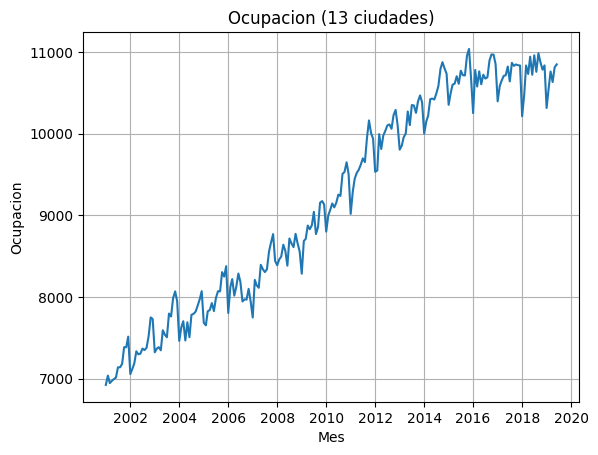

In [17]:
# imprimiendo el tamaño del dataframe
print(data.shape)

# Graficando los datos
plt.title("Ocupacion (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Ocupacion")
plt.plot(data[["Ocupados"]])
plt.grid()
plt.show()

Para la realización del ejercicio se escogio la cantidad de ocupados en las 13 ciudades principales, esto serie de tiempo muestra una variación estacional ascendente, pero para los ultimos años tiene a ser estable, siguiendo la estacionalidad.

## **3. Encontrando los componentes de una serie de tiempo**

En algunas ocasiones puede ser útil empezar nuestro análisis descomponiendo la serie de tiempo en sus componentes: **tendencia**, **estacionalidad** y **componente puramente aleatorio**. Una forma de hacer esto es empleando la función seasonal_decompose.

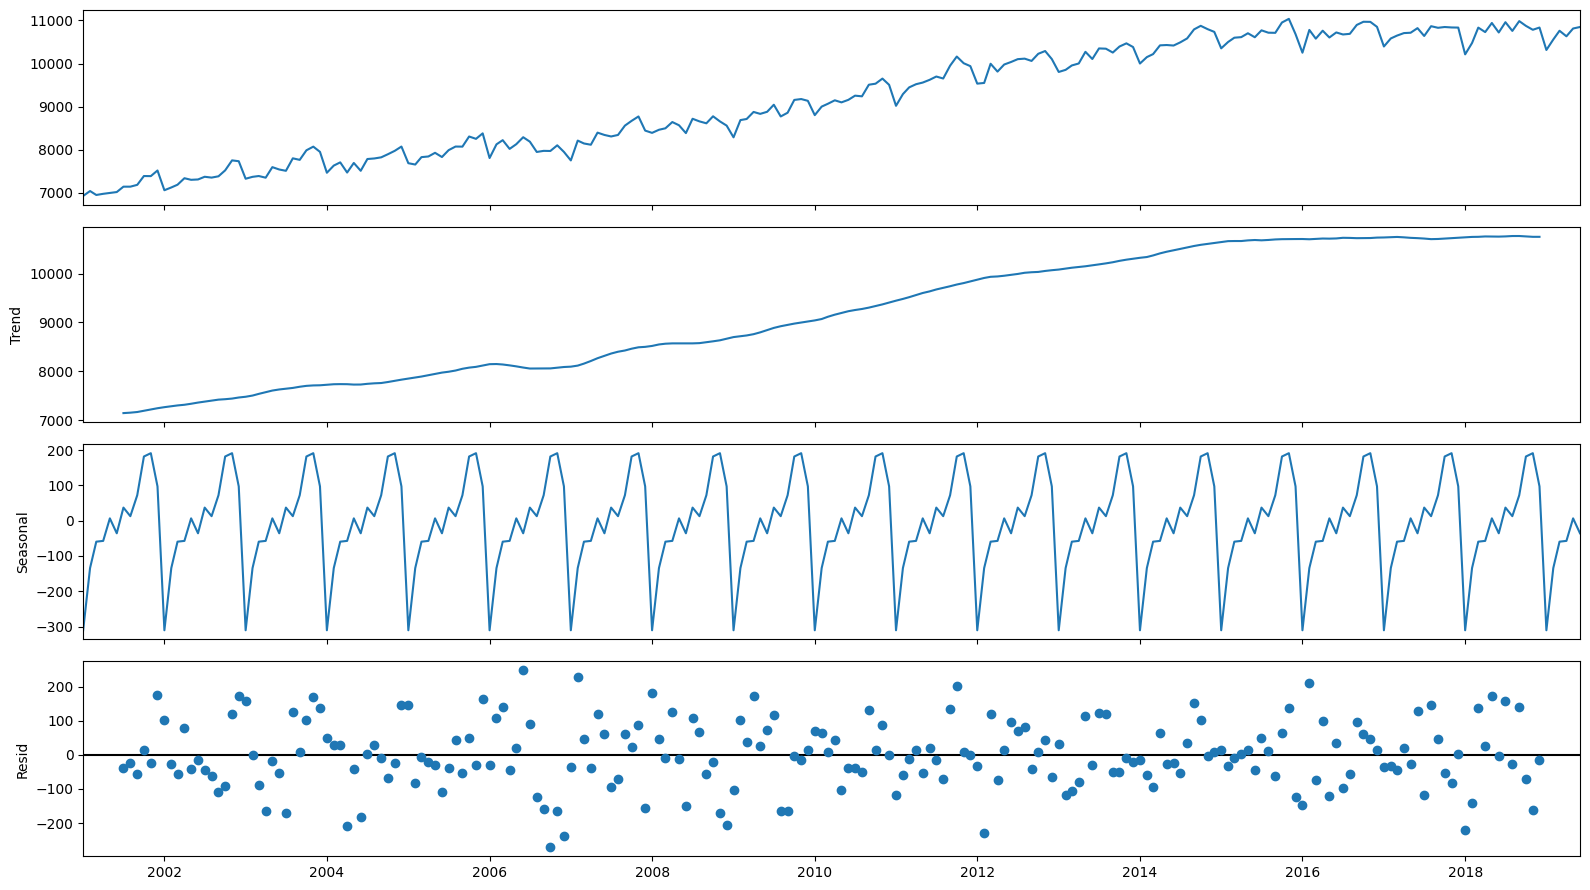

In [18]:
td_componentes = seasonal_decompose(data[["Ocupados"]],model="additive")
fig = td_componentes.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

Asi se extrae cada elemento de la descomposición de la serie.

In [19]:
td_componentes.seasonal
#td_componentes.trend
#td_componentes.resid

,seasonal
mes,
2001-01-01,-310.570069
2001-02-01,-134.331549
2001-03-01,-59.585841
2001-04-01,-57.385905
2001-05-01,6.435912
...,...
2019-02-01,-134.331549
2019-03-01,-59.585841
2019-04-01,-57.385905


La componente estacional muestra el comportamiento recurrente de la serie a lo largo de los meses. Los resultados indican que existen meses en los que históricamente el número de ocupados tiende a estar por encima o por debajo de la tendencia general. Por ejemplo, algunos meses presentan valores negativos, lo que significa una disminución estacional en el nivel de ocupación, mientras que otros meses presentan valores positivos, reflejando aumentos temporales en el empleo. Además, los valores se repiten cada año, lo cual confirma la presencia de un patrón estacional mensual en la serie de ocupados de las 13 principales ciudades.

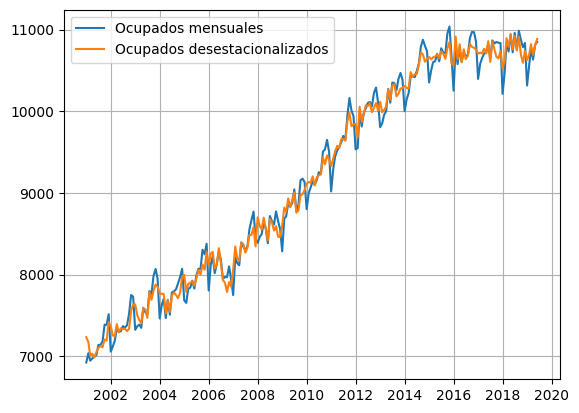

In [20]:
ocupados_desestacionalizada = data["Ocupados"]-td_componentes.seasonal

plt.plot(data[["Ocupados"]],label="Ocupados mensuales")
plt.plot(ocupados_desestacionalizada,label="Ocupados desestacionalizados")
plt.legend()
plt.grid()
plt.show()

## **4. Protocolo de evaluación**

Antes de continuar es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample). Guardemos un año de datos.

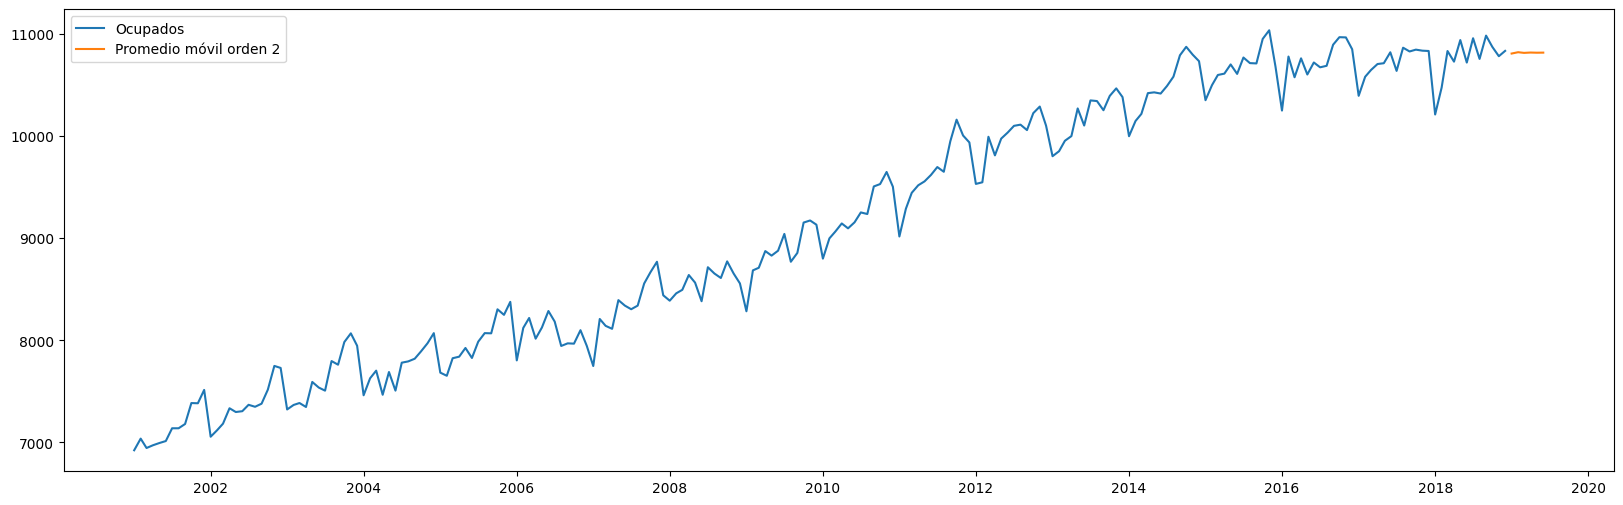

In [42]:
fig = plt.figure(figsize=(20, 6))

plt.plot(train_ocupados,label="Ocupados")
plt.plot(ma_2_f,label="Promedio móvil orden 2")

plt.legend()
plt.show()

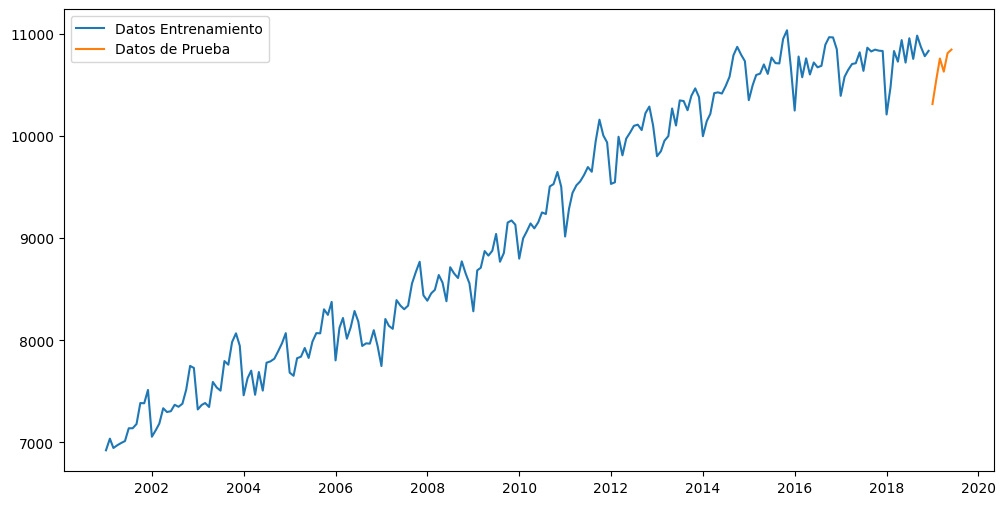

In [23]:
train_len = len(data)-6

train_ocupados = data[["Ocupados"]][:train_len]
test_ocupados = data[["Ocupados"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados,label="Datos Entrenamiento")
plt.plot(test_ocupados,label="Datos de Prueba")
plt.legend()
plt.show()

In [24]:
train_ocupados

,Ocupados
mes,
2001-01-01,6923.604
2001-02-01,7037.746
2001-03-01,6945.973
2001-04-01,6973.079
2001-05-01,6994.462
...,...
2018-08-01,10756.782
2018-09-01,10984.928
2018-10-01,10874.338


In [25]:
test_ocupados

,Ocupados
mes,
2019-01-01,10314.438
2019-02-01,10557.917
2019-03-01,10760.776
2019-04-01,10632.028
2019-05-01,10813.000
2019-06-01,10848.000


## **5. Promedio movil**

El promedio móvil está dado por:

$$ F_{t + 1}=\frac{Y_{t} + Y_{t-1} + Y_{t-(k-1)} }{ k} $$

El método de los promedios móviles utiliza el promedio de los $k$
valores de datos más recientes en la serie de tiempo como el
pronóstico para el siguiente periodo.

El término móvil indica que, mientras se dispone de una nueva
observación para la serie de tiempo, reemplaza a la observación más
antigua de la ecuación anterior y se calcula un promedio nuevo.
Como resultado, el promedio cambiará, o se moverá, conforme surjan
nuevas observaciones.

$Y_{t}$ = Observación en el período t

$F_{t}$ = Pronóstico en el período t

In [27]:
## Considerando el dato actual
ma_2 = train_ocupados.rolling(2,min_periods=2).mean()
ma_3 = train_ocupados.rolling(3,min_periods=2).mean()
ma_4 = train_ocupados.rolling(4,min_periods=2).mean()
ma_5 = train_ocupados.rolling(5,min_periods=2).mean()
ma_6 = train_ocupados.rolling(6,min_periods=2).mean()
ma_7 = train_ocupados.rolling(7,min_periods=2).mean()
ma_8 = train_ocupados.rolling(8,min_periods=2).mean()

## Sin considerar el dato actual
ma_2 = train_ocupados.shift().rolling(2,min_periods=2).mean()
ma_3 = train_ocupados.shift().rolling(3,min_periods=2).mean()
ma_4 = train_ocupados.shift().rolling(4,min_periods=2).mean()
ma_5 = train_ocupados.shift().rolling(5,min_periods=2).mean()
ma_6 = train_ocupados.shift().rolling(6,min_periods=2).mean()
ma_7 = train_ocupados.shift().rolling(7,min_periods=2).mean()
ma_8 = train_ocupados.shift().rolling(8,min_periods=2).mean()

In [29]:
def fore_ma(datos,w,h):
  data = datos.copy()

  for x in range(1,h+1):
    ind = data.index[-1]
    value = ind + pd.DateOffset(months=1)
    data.loc[value] = data[-w:].mean()

  return data[-h:]

In [31]:
ma_2_f = fore_ma(train_ocupados,2,6)
ma_3_f = fore_ma(train_ocupados,3,6)
ma_4_f = fore_ma(train_ocupados,4,6)
ma_5_f = fore_ma(train_ocupados,5,6)
ma_6_f = fore_ma(train_ocupados,6,6)
ma_7_f = fore_ma(train_ocupados,7,6)
ma_8_f = fore_ma(train_ocupados,8,6)

In [32]:
test_ocupados

ma_2_f

,Ocupados
mes,
2019-01-01,10809.348500
2019-02-01,10822.373250
2019-03-01,10815.860875
2019-04-01,10819.117063
2019-05-01,10817.488969
2019-06-01,10818.303016


In [33]:
rmse_ma_2 = np.sqrt(mean_squared_error(test_ocupados,ma_2_f))
rmse_ma_3 = np.sqrt(mean_squared_error(test_ocupados,ma_3_f))
rmse_ma_4 = np.sqrt(mean_squared_error(test_ocupados,ma_4_f))
rmse_ma_5 = np.sqrt(mean_squared_error(test_ocupados,ma_5_f))
rmse_ma_6 = np.sqrt(mean_squared_error(test_ocupados,ma_6_f))
rmse_ma_7 = np.sqrt(mean_squared_error(test_ocupados,ma_7_f))
rmse_ma_8 = np.sqrt(mean_squared_error(test_ocupados,ma_8_f))

print(
    rmse_ma_2,
    rmse_ma_3,
    rmse_ma_4,
    rmse_ma_5,
    rmse_ma_6,
    rmse_ma_7,
    rmse_ma_8
)

242.8347290019203 250.36984465630144 270.6203851653251 266.5247179311155 272.83744069293607 269.605171526337 270.14397611273165


In [39]:
resultados_rmse = pd.DataFrame({
    "Modelo": [
        "MA(2)",
        "MA(3)",
        "MA(4)",
        "MA(5)",
        "MA(6)",
        "MA(7)",
        "MA(8)"
    ],

    "Ventana": [2,3,4,5,6,7,8],

    "Tipo": [
        "Sin dato actual",
        "Sin dato actual",
        "Sin dato actual",
        "Sin dato actual",
        "Sin dato actual",
        "Sin dato actual",
        "Sin dato actual"
    ],

    "RMSE": [
        rmse_ma_2,
        rmse_ma_3,
        rmse_ma_4,
        rmse_ma_5,
        rmse_ma_6,
        rmse_ma_7,
        rmse_ma_8
    ]
})

resultados_rmse = resultados_rmse.sort_values(by="RMSE")

resultados_rmse

,Modelo,Ventana,Tipo,RMSE
0,MA(2),2,Sin dato actual,242.834729
1,MA(3),3,Sin dato actual,250.369845
3,MA(5),5,Sin dato actual,266.524718
5,MA(7),7,Sin dato actual,269.605172
6,MA(8),8,Sin dato actual,270.143976
2,MA(4),4,Sin dato actual,270.620385
4,MA(6),6,Sin dato actual,272.837441


In [41]:
# Función para pronóstico promedio móvil

def fore_ma(datos,w,h):

    data = datos.copy()

    for x in range(1,h+1):

        ind = data.index[-1]
        value = ind + pd.DateOffset(months=1)

        data.loc[value] = data[-w:].mean()

    return data[-h:]


# Ventanas
ventanas = [2,3,4,5,6,7,8]

# Lista resultados
resultados = []


for w in ventanas:

    # ====================================
    # 1. Con dato actual
    # ====================================

    ma_actual = train_ocupados.rolling(
        w,
        min_periods=w
    ).mean()

    actual_df = pd.concat(
        [train_ocupados, ma_actual],
        axis=1
    ).dropna()

    rmse_actual = np.sqrt(
        mean_squared_error(
            actual_df.iloc[:,0],
            actual_df.iloc[:,1]
        )
    )


    # ====================================
    # 2. Sin dato actual
    # ====================================

    ma_shift = train_ocupados.shift().rolling(
        w,
        min_periods=w
    ).mean()

    shift_df = pd.concat(
        [train_ocupados, ma_shift],
        axis=1
    ).dropna()

    rmse_shift = np.sqrt(
        mean_squared_error(
            shift_df.iloc[:,0],
            shift_df.iloc[:,1]
        )
    )


    # ====================================
    # 3. Forecast real
    # ====================================

    ma_forecast = fore_ma(train_ocupados,w,6)

    rmse_forecast = np.sqrt(
        mean_squared_error(
            test_ocupados,
            ma_forecast
        )
    )


    # Guardar resultados

    resultados.append([
        w,
        rmse_actual,
        rmse_shift,
        rmse_forecast
    ])


# Tabla final

tabla_resultados = pd.DataFrame(
    resultados,
    columns=[
        "Ventana",
        "RMSE Con dato actual",
        "RMSE Sin dato actual",
        "RMSE Forecast"
    ]
)

# Ordenar por mejor forecast

tabla_resultados = tabla_resultados.sort_values(
    by="RMSE Forecast"
)

tabla_resultados

,Ventana,RMSE Con dato actual,RMSE Sin dato actual,RMSE Forecast
0,2,94.217036,191.402111,242.834729
1,3,127.601407,197.160992,250.369845
3,5,161.244641,204.060665,266.524718
5,7,178.728816,211.536626,269.605172
6,8,185.094548,216.405586,270.143976
2,4,147.870744,201.555801,270.620385
4,6,170.050554,208.516952,272.837441


Después de evaluar diferentes modelos de promedio móvil con ventanas entre 2 y 8 meses, se seleccionó el promedio móvil de orden 2 (MA(2)) como el mejor modelo para realizar el pronóstico de ocupados. La selección se realizó comparando el desempeño de cada modelo mediante el error cuadrático medio (RMSE), utilizando tres metodologías: promedio móvil con dato actual, promedio móvil sin considerar el dato actual y forecast real. El criterio principal de selección fue el RMSE Forecast, ya que este evalúa la capacidad predictiva real del modelo sobre los últimos 6 meses de datos. El modelo MA(2) presentó el menor error de pronóstico, con un RMSE de aproximadamente 242.83, lo que indica un mejor ajuste respecto a las demás ventanas evaluadas. Estos resultados sugieren que los valores más recientes contienen mayor información relevante para predecir el comportamiento futuro de la serie de ocupados.

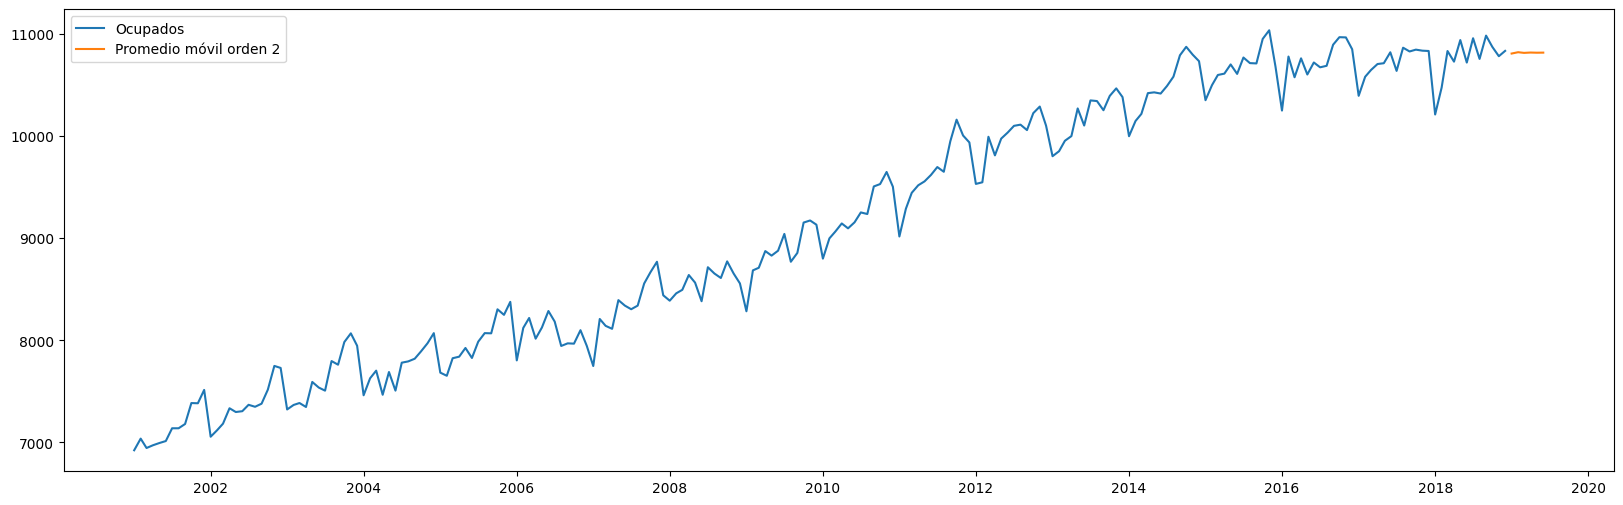

In [43]:
fig = plt.figure(figsize=(20, 6))

plt.plot(train_ocupados,label="Ocupados")
plt.plot(ma_2_f,label="Promedio móvil orden 2")

plt.legend()
plt.show()

Ahora ya hemos realizado el entrenamiento, entendiendo que la ventana con 2 meses fue la mejor, entonces tomamos todos los datos y relizamos el pronostico de los siguientes 6 meses

In [44]:
forecast_final = fore_ma(data[["Ocupados"]],2,6)

forecast_final

,Ocupados
mes,
2019-07-01,10830.500000
2019-08-01,10839.250000
2019-09-01,10834.875000
2019-10-01,10837.062500
2019-11-01,10835.968750
2019-12-01,10836.515625


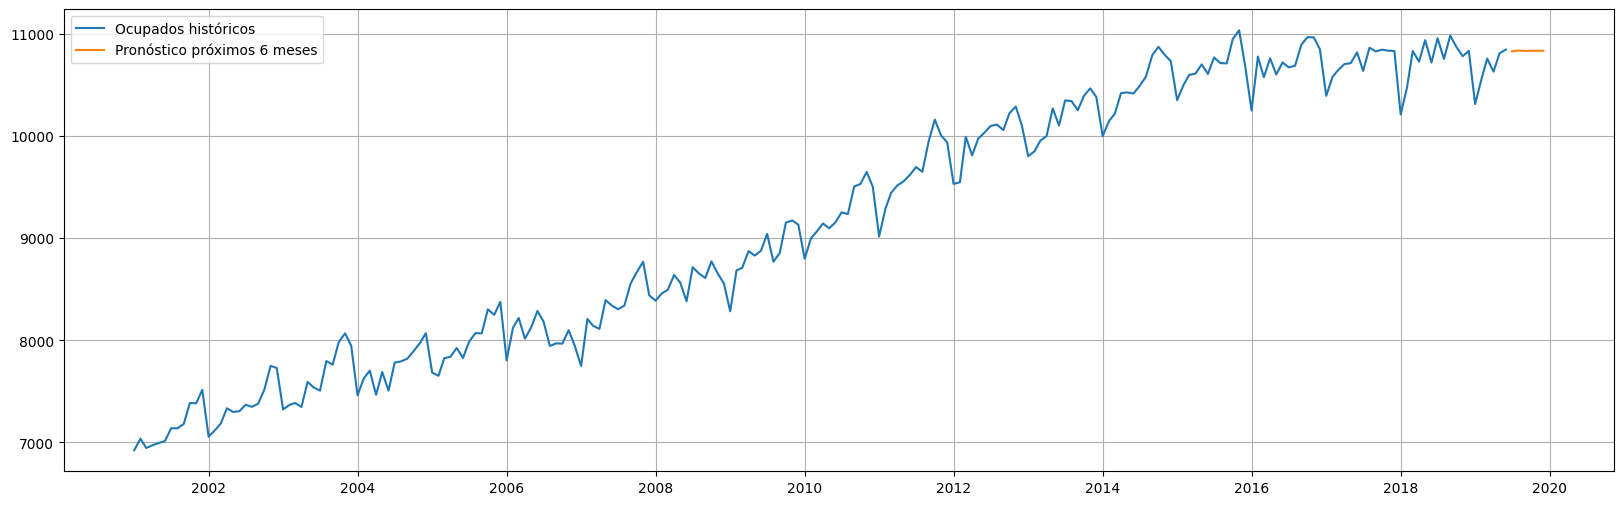

In [45]:
fig = plt.figure(figsize=(20,6))

plt.plot(data[["Ocupados"]],label="Ocupados históricos")
plt.plot(forecast_final,label="Pronóstico próximos 6 meses")

plt.legend()
plt.grid()
plt.show()

El promedio móvil de orden 2 presentó el menor RMSE Forecast, por lo que fue seleccionado como el mejor modelo para proyectar el número de ocupados en las 13 principales ciudades. Los resultados sugieren que la dinámica reciente de la serie contiene mayor capacidad predictiva que observaciones más antiguas.

Una limitación del modelo es que el promedio móvil utiliza únicamente información histórica de la serie y no incorpora variables económicas externas que podrían afectar el empleo, como crecimiento económico, inflación, cambios de política pública o choques inesperados. Además, al tratarse de un método relativamente simple, puede tener dificultades para capturar cambios estructurales o variaciones abruptas en la tendencia de la serie.
